In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_digits # Importa el conjunto de datos de dígitos manuscritos
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [3]:
data = load_digits() # Carga el conjunto de datos de dígitos manuscritos
X = data.data # Características (imágenes de dígitos)
y = data.target # Etiquetas (dígitos correspondientes)
print(data.DESCR) # Muestra una descripción del conjunto de datos

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 1797
    :Number of Attributes: 64
    :Attribute Information: 8x8 image of integer pixels in the range 0..16.
    :Missing Attribute Values: None
    :Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
    :Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each blo

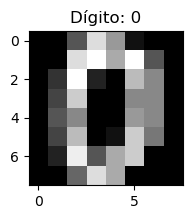

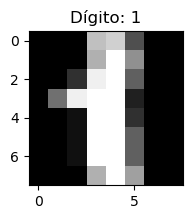

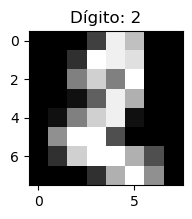

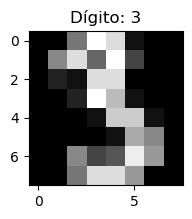

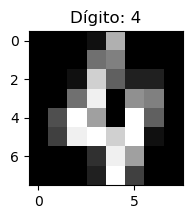

In [8]:
def show_data(X, y, index):
    """Función para mostrar una imagen de dígito dado su índice."""
    plt.figure(figsize=(2,2))
    plt.imshow(X[index].reshape(8, 8), cmap='gray', interpolation='nearest')
    plt.title(f'Dígito: {y[index]}')
    plt.show()

for i in range(5):
    show_data(X, y, i)  # Muestra las primeras cinco imágenes de dígitos

In [9]:
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [10]:
# Escalado de datos
X_min = X.min()
X_max = X.max()
X = (X - X_min) / (X_max - X_min) # Normalización de los datos al rango [0, 1] usualmente mejora el rendimiento de los modelos SVM

In [11]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Probamos con un árbol de clasificación (optimizado con hiperparámetros)

In [15]:
rango_max_depth = list(range(5, 17)) # Profundidad máxima del árbol
rango_min_samples_leaf = list(range(2, 21, 2)) # Mínimo número de muestras por hoja
rango_max_leaf_nodes = list(range(30, 51, 2)) # Número máximo de nodos hoja
param_grid = {
    'max_depth': rango_max_depth,
    'min_samples_leaf': rango_min_samples_leaf,
    'max_leaf_nodes': rango_max_leaf_nodes
}

In [16]:
gridCV = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=10, n_jobs=-1)
gridCV.fit(X_train, y_train)
print("Mejores hiperparámetros:", gridCV.best_params_)
best_tree = gridCV.best_estimator_
y_pred = best_tree.predict(X_test)
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("Precisión:", accuracy_score(y_test, y_pred))

Mejores hiperparámetros: {'max_depth': 10, 'max_leaf_nodes': 48, 'min_samples_leaf': 4}
Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        33
           1       0.71      0.79      0.75        28
           2       0.92      0.70      0.79        33
           3       0.83      0.85      0.84        34
           4       0.70      0.87      0.78        46
           5       0.90      0.96      0.93        47
           6       0.89      0.91      0.90        35
           7       0.80      0.82      0.81        34
           8       0.81      0.70      0.75        30
           9       0.86      0.75      0.80        40

    accuracy                           0.83       360
   macro avg       0.84      0.83      0.83       360
weighted avg       0.84      0.83      0.83       360

Matriz de confusión:
 [[30  0  0  0  2  1  0  0  0  0]
 [ 0 22  1  0  2  0  0  1  1  1]
 [ 0  1 23  3  1  0  1  2  0  2]
 [ 0 